In [1]:
import wandb
import pandas as pd
import numpy as np
import json
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(path="harvardml/opt-olmo")

In [4]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',   'NovoGrad', 'Adafactor', 'Lion', 'Signum', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [5]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 25000
groups = ["sgd-150-1"]
plot_key = "learning_rate"
display_key = "Learning Rate"

for run in runs:
    if run.group in groups:
        history = run.history(samples=50000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict[plot_key] = run.config["optimizer"][plot_key]
        run_dict["dampening"] = run.config["optimizer"]["dampening"]
        run_dict["momentum"] = run.config["optimizer"]["beta_0"]

        if run.group == "optimizers-1" and run_dict["optimizer"] == "sgdw":
            continue
        
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

KeyError: 'dampening'

In [ ]:
df

,id,group,optimizer,learning_rate,dampening,momentum,val_loss,step
0,qet4fpx9,sgd-150-1,sgdw,100.00000,0.98,0.98,10.000000,NaN
0,owihqeo6,sgd-150-1,sgdw,1000.00000,0.95,0.95,NaN,NaN
0,g5b9k8mi,sgd-150-1,sgdw,31.60000,0.98,0.98,3.206082,25000.0
0,7p25pig7,sgd-150-1,sgdw,316.00000,0.95,0.95,10.000000,NaN
0,o3eumemu,sgd-150-1,sgdw,316.00000,0.80,0.80,10.000000,NaN
...,...,...,...,...,...,...,...,...
0,21606vkg,sgd-150-1,sgdw,0.00316,0.90,0.90,6.627858,25000.0
0,1rh98sdt,sgd-150-1,sgdw,1.00000,0.00,0.90,3.301057,25000.0
0,0sydkiqd,sgd-150-1,sgdw,0.03160,0.00,0.90,4.198138,25000.0
0,0i2dg0xm,sgd-150-1,sgdw,0.10000,0.00,0.90,3.673190,25000.0


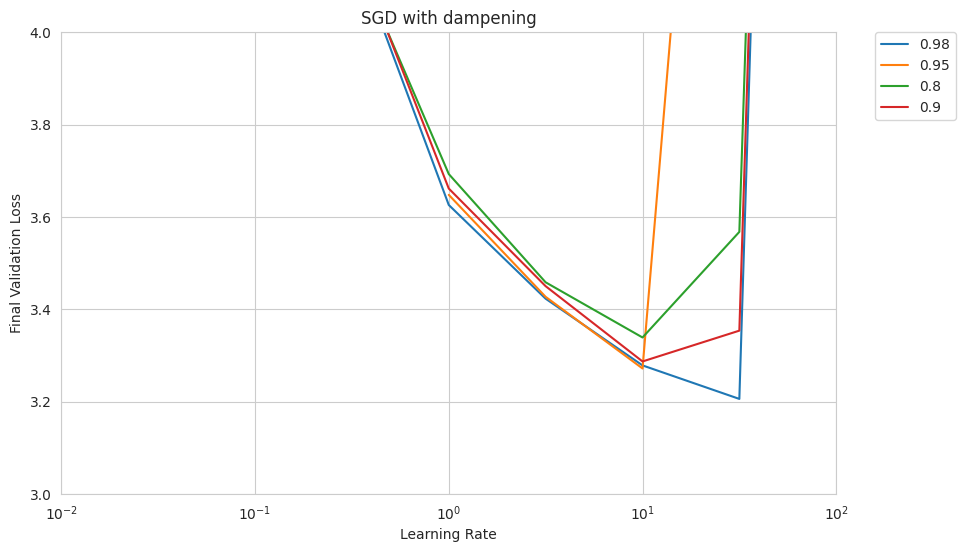

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))  # Larger figure size

group_df = df[df["dampening"] != 0.0]

momentums = df["momentum"].unique()

best_lrs = {}
for mom in momentums:
    mom_df = group_df[group_df["momentum"] == mom]
    mom_df = mom_df.sort_values(by=plot_key)
    mom_df = mom_df.groupby(plot_key).min().reset_index()
    plt.plot(mom_df[plot_key], mom_df["val_loss"], label=mom, ) #color=color_map[optimizer])
    
    best_lr = mom_df[plot_key][mom_df["val_loss"].idxmin()]
    best_lrs[mom] = best_lr

plt.xscale("log")
#plt.yscale("log")
plt.xlim(1e-2, 1e2)
plt.ylim(3, 4)
plt.legend()
plt.xlabel(display_key)
plt.ylabel("Final Validation Loss")
plt.title("SGD with dampening")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

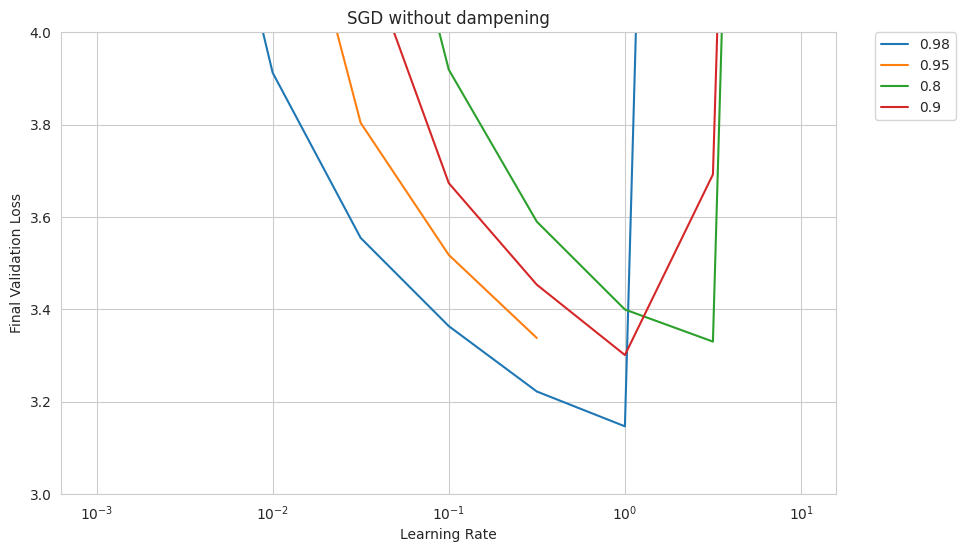

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))  # Larger figure size

group_df = df[df["dampening"] == 0.0]

momentums = df["momentum"].unique()

best_lrs = {}
for mom in momentums:
    mom_df = group_df[group_df["momentum"] == mom]
    mom_df = mom_df.sort_values(by=plot_key)
    mom_df = mom_df.groupby(plot_key).min().reset_index()
    plt.plot(mom_df[plot_key], mom_df["val_loss"], label=mom, ) #color=color_map[optimizer])
    
    best_lr = mom_df[plot_key][mom_df["val_loss"].idxmin()]
    best_lrs[mom] = best_lr

plt.xscale("log")
#plt.yscale("log")
plt.ylim(3, 4)
plt.legend()
plt.xlabel(display_key)
plt.ylabel("Final Validation Loss")
plt.title("SGD without dampening")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

df_div = df.copy()

adam_lr = best_lrs["adamw"]
multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

for optimizer in optimizers:
    if optimizer in df["optimizer"].unique():
        optimizer_df = df[df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by="learning_rate")
        # take minimal value for each learning rate
        optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
        plt.plot(
            multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
            optimizer_df["val_loss"], 
            label=name_map[optimizer],
            linewidth=2,
            color=color_map[optimizer],
            linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
        )

plt.xscale("log")
plt.xlim(3.2e-2, 1.5e2)
plt.ylim(2.85, 3.2)
plt.xlabel("Multiple of optimal LR")
plt.ylabel("Final Validation Loss")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers) /2)
plt.show()

KeyError: 'adamw'

<Figure size 1000x600 with 0 Axes>

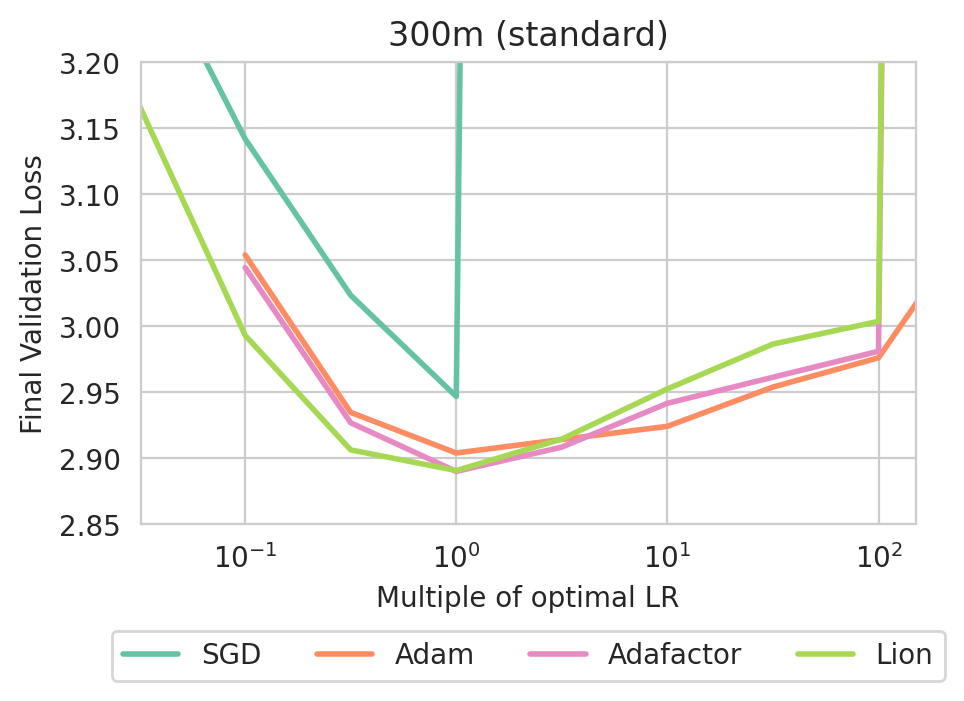

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

df_div = df.copy()

adam_lr = best_lrs["adamw"]
multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

for optimizer in optimizers:
    if optimizer in ["sophiag", "novagradw_ours", "signsgd"]:
        continue
    if optimizer in df["optimizer"].unique():
        optimizer_df = df[df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by="learning_rate")
        # take minimal value for each learning rate
        optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
        plt.plot(
            multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
            optimizer_df["val_loss"], 
            label=name_map[optimizer],
            linewidth=2,
            color=color_map[optimizer],
            # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
        )

plt.xscale("log")
plt.xlim(3.2e-2, 1.5e2)
plt.ylim(2.85, 3.2)
plt.xlabel("Multiple of optimal LR")
plt.ylabel("Final Validation Loss")
plt.title("300m (standard)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))
plt.show()